#  EDA — Exploration du LIAR Dataset

**Projet 3 — Détection automatique de Fake News politiques**

Ce notebook :
- Télécharge et charge les 3 splits du LIAR Dataset
- Fusionne les splits en un fichier unifié
- Analyse la distribution des labels, speakers, partis
- Produit toutes les visualisations EDA
- Sauvegarde les données traitées en `.parquet`

## 0. Imports & Configuration

In [24]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Création des dossiers si absents
for d in ['../data/brutes', '../data/fusionnes', '../data/traitees',
          '../data/modeles', '../Doc']:
    os.makedirs(d, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12

COLS = ['id','label','statement','subject','speaker','job',
        'state','party','barely_true_c','false_c','half_true_c',
        'mostly_true_c','pants_on_fire_c','context']

LABEL_ORDER  = ['pants-fire','false','barely-true','half-true','mostly-true','true']
LABEL_COLORS = ['#E24B4A','#F09595','#FAC775','#97C459','#5DCAA5','#1D9E75']

LABEL_MAP = {
    'pants-fire': 0, 'false': 0, 'barely-true': 0,
    'half-true': 1, 'mostly-true': 1, 'true': 1
}

print(' Imports OK')

 Imports OK


## 1. Téléchargement & Chargement du LIAR Dataset

In [25]:
BASE_URL = 'https://raw.githubusercontent.com/tfs4/liar_dataset/master/'

for fname in ['train.tsv', 'valid.tsv', 'test.tsv']:
    dest = f'../data/brutes/{fname}'
    if not os.path.exists(dest):
        print(f' Téléchargement {fname}...')
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    else:
        print(f' {fname} déjà présent')

 train.tsv déjà présent
 valid.tsv déjà présent
 test.tsv déjà présent


In [26]:
train_df = pd.read_csv('../data/brutes/train.tsv', sep='\t', names=COLS, header=None)
val_df   = pd.read_csv('../data/brutes/valid.tsv', sep='\t', names=COLS, header=None)
test_df  = pd.read_csv('../data/brutes/test.tsv',  sep='\t', names=COLS, header=None)

# Ajout colonne split
train_df['split'] = 'train'
val_df['split']   = 'val'
test_df['split']  = 'test'

# Fusion
liar_unifie = pd.concat([train_df, val_df, test_df], ignore_index=True)
liar_unifie['binary_label'] = liar_unifie['label'].map(LABEL_MAP)

print(f'Train  : {len(train_df):,}')
print(f'Val    : {len(val_df):,}')
print(f'Test   : {len(test_df):,}')
print(f'Total  : {len(liar_unifie):,}')
liar_unifie.head(3)

Train  : 10,240
Val    : 1,284
Test   : 1,267
Total  : 12,791


,id,label,statement,subject,speaker,job,state,party,barely_true_c,false_c,half_true_c,mostly_true_c,pants_on_fire_c,context,split,binary_label
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,train,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,train,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,train,1


In [27]:
# Sauvegarde fichier unifié (CSV + parquet)
liar_unifie.to_csv('../data/fusionnes/liar_unifie.csv', index=False)
liar_unifie.to_parquet('../data/traitees/liar_unifie_raw.parquet', index=False)
print(' data/fusionnes/liar_unifie.csv')
print(' data/traitees/liar_unifie_raw.parquet')

 data/fusionnes/liar_unifie.csv
 data/traitees/liar_unifie_raw.parquet


## 2. Distribution des 6 labels de véracité

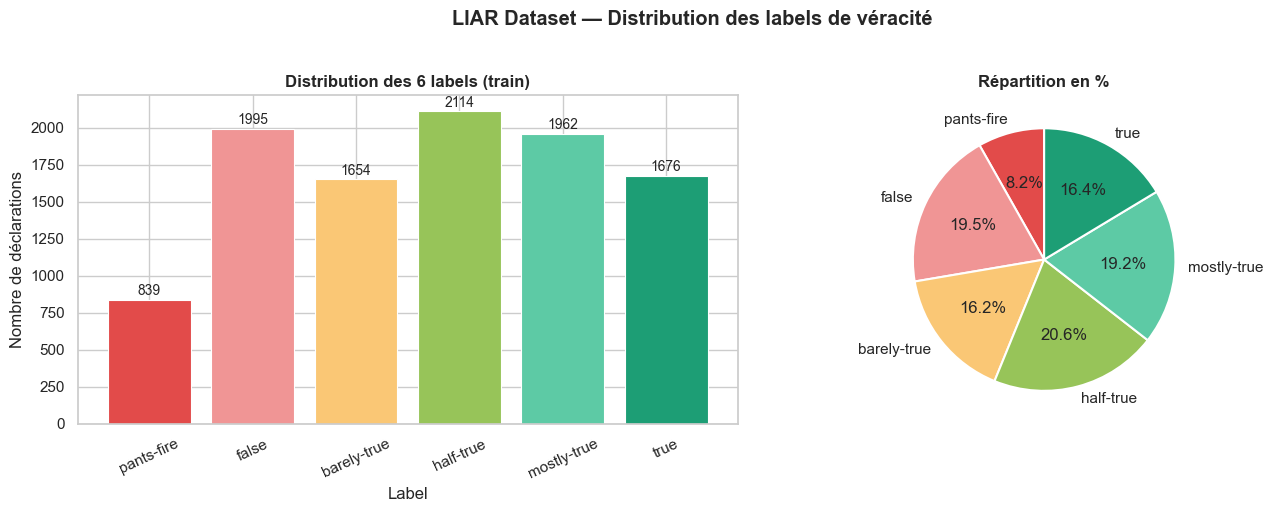


 Doc/EDA_01_distribution_labels.png


In [28]:
counts = train_df['label'].value_counts().reindex(LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color=LABEL_COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution des 6 labels (train)', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Nombre de déclarations')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, colors=LABEL_COLORS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Répartition en %', fontweight='bold')

plt.suptitle('LIAR Dataset — Distribution des labels de véracité', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Doc/EDA_01_distribution_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Doc/EDA_01_distribution_labels.png')

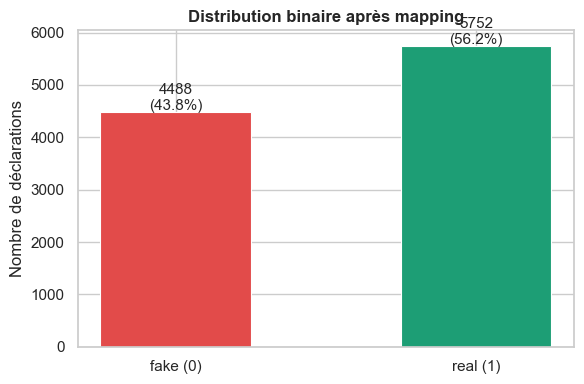

In [29]:
# Distribution binaire (après mapping)
binary_counts = train_df['label'].map(LABEL_MAP).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['fake (0)', 'real (1)'], binary_counts.reindex([0,1]).values,
       color=['#E24B4A','#1D9E75'], edgecolor='white', linewidth=0.8, width=0.5)
ax.set_title('Distribution binaire après mapping', fontweight='bold')
ax.set_ylabel('Nombre de déclarations')
for i, v in enumerate(binary_counts.reindex([0,1]).values):
    ax.text(i, v + 30, f'{v}\n({v/len(train_df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../Doc/EDA_02_distribution_binaire.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse des speakers et partis politiques

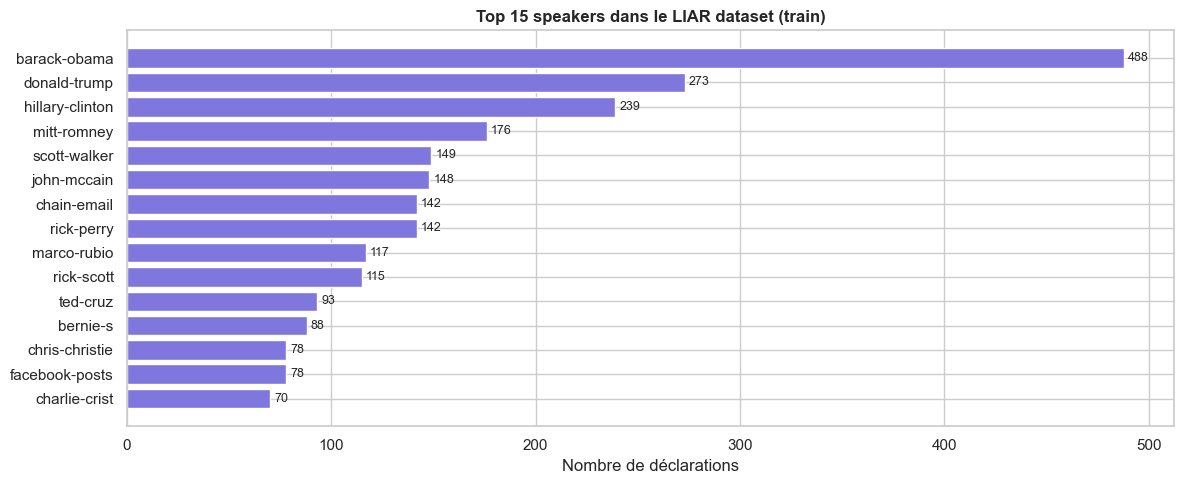

In [30]:
# Top 15 speakers
top_speakers = train_df['speaker'].value_counts().head(15)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_speakers.index[::-1], top_speakers.values[::-1],
                color='#7F77DD', edgecolor='white')
plt.title('Top 15 speakers dans le LIAR dataset (train)', fontweight='bold')
plt.xlabel('Nombre de déclarations')
for bar, val in zip(bars, top_speakers.values[::-1]):
    plt.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../Doc/EDA_03_top_speakers.png', dpi=150, bbox_inches='tight')
plt.show()

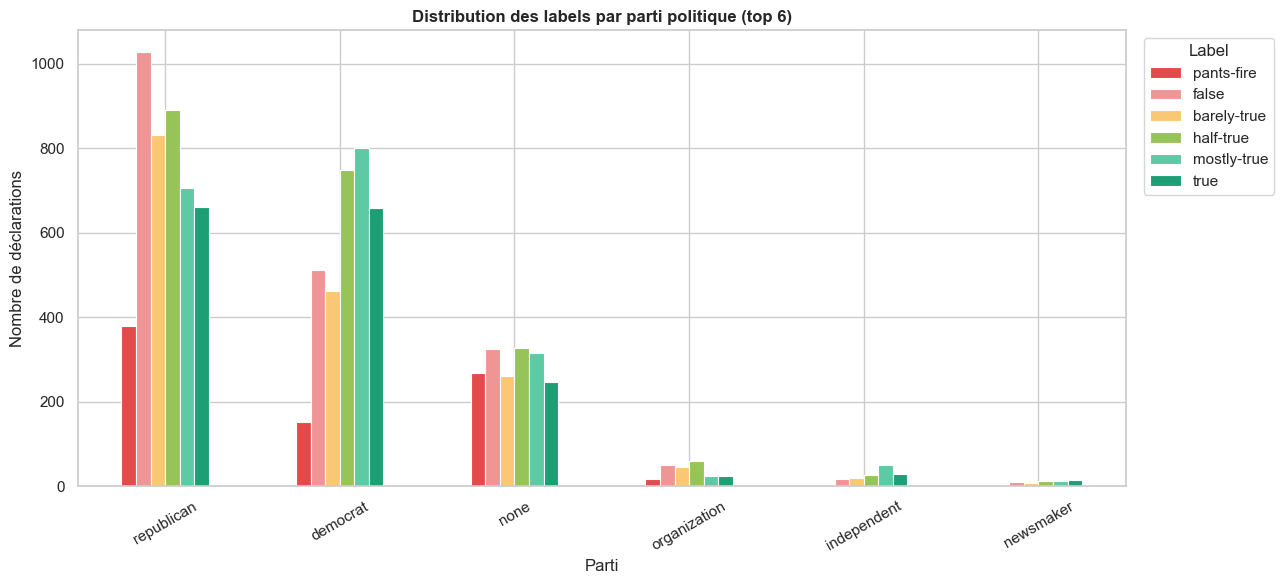

In [31]:
# Labels par parti politique
top_parties = train_df['party'].value_counts().head(6).index
party_label = (
    train_df.groupby(['party','label']).size()
    .unstack(fill_value=0)
    .loc[top_parties, LABEL_ORDER]
)
party_label.plot(kind='bar', figsize=(13, 6), color=LABEL_COLORS,
                 edgecolor='white', linewidth=0.8)
plt.title('Distribution des labels par parti politique (top 6)', fontweight='bold')
plt.xlabel('Parti')
plt.ylabel('Nombre de déclarations')
plt.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../Doc/EDA_04_labels_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analyse de la longueur des déclarations

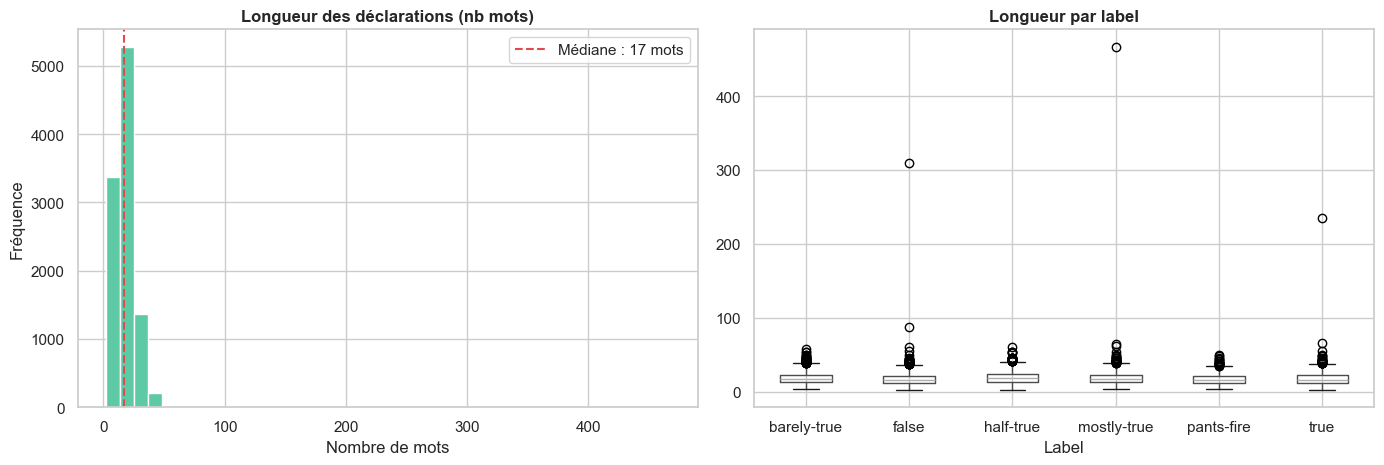

Longueur moyenne  : 18.0 mots
Longueur médiane  : 17 mots
Longueur max      : 467 mots


In [32]:
train_df['text_length'] = train_df['statement'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=40, color='#5DCAA5', edgecolor='white')
axes[0].axvline(train_df['text_length'].median(), color='#E24B4A', linestyle='--',
                label=f'Médiane : {train_df["text_length"].median():.0f} mots')
axes[0].set_title('Longueur des déclarations (nb mots)', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

train_df.boxplot(column='text_length', by='label', ax=axes[1])
axes[1].set_title('Longueur par label', fontweight='bold')
axes[1].set_xlabel('Label')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../Doc/EDA_05_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Longueur moyenne  : {train_df["text_length"].mean():.1f} mots')
print(f'Longueur médiane  : {train_df["text_length"].median():.0f} mots')
print(f'Longueur max      : {train_df["text_length"].max()} mots')

## 6. Pré-traitement & Features textuelles n_chars / n_tokens

> Conformément au rapport (section 3.1) : nettoyage léger, remplacement NaN, création de `n_chars` et `n_tokens`.

In [33]:
# Suppression lignes sans texte (sécurisation pipeline)
before = len(liar_unifie)
liar_unifie = liar_unifie[liar_unifie['statement'].notna() & (liar_unifie['statement'].str.strip() != '')]
print(f'Lignes supprimées : {before - len(liar_unifie)} ({(before-len(liar_unifie))/before*100:.1f}%)')

# Remplacement NaN dans les métadonnées par 'unknown'
for col in ['speaker', 'party', 'subject', 'job', 'state', 'context']:
    liar_unifie[col] = liar_unifie[col].fillna('unknown')

# Création des features textuelles
liar_unifie['n_chars']  = liar_unifie['statement'].apply(len)
liar_unifie['n_tokens'] = liar_unifie['statement'].apply(lambda x: len(x.split()))

print('\n Statistiques features textuelles :')
print(liar_unifie[['n_chars', 'n_tokens']].describe().round(2))

Lignes supprimées : 0 (0.0%)

 Statistiques features textuelles :
        n_chars  n_tokens
count  12791.00  12791.00
mean     107.16     18.04
std       63.45     10.13
min       11.00      2.00
25%       73.00     12.00
50%       99.00     17.00
75%      133.00     22.00
max     3192.00    467.00


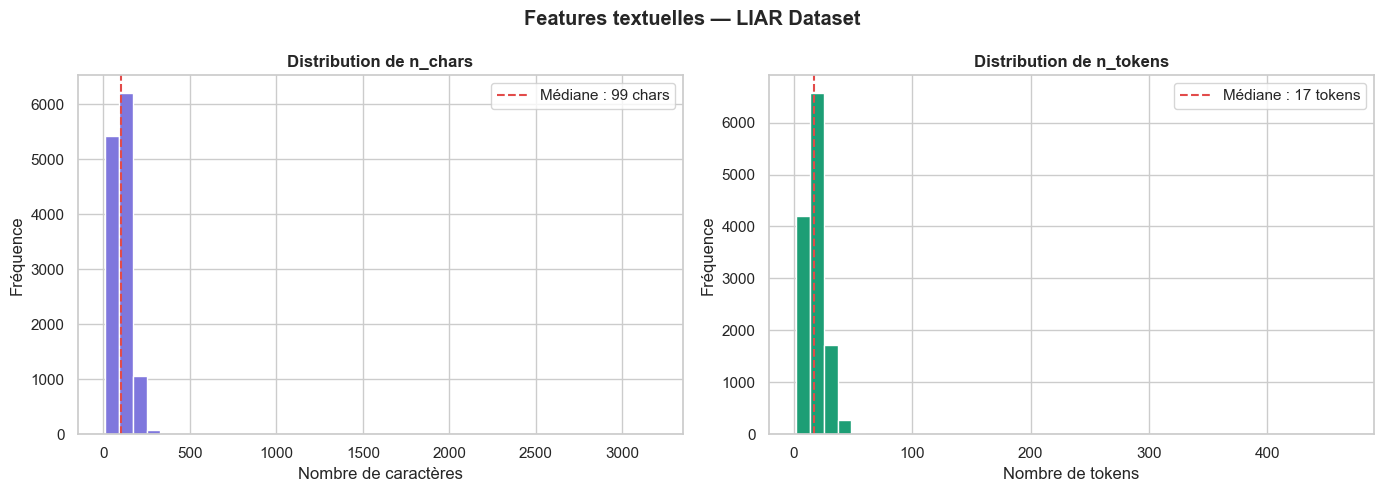

💾 Doc/EDA_06_nchars_ntokens.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liar_unifie['n_chars'], bins=40, color='#7F77DD', edgecolor='white')
axes[0].axvline(liar_unifie['n_chars'].median(), color='#E24B4A', linestyle='--',
                label=f'Médiane : {liar_unifie["n_chars"].median():.0f} chars')
axes[0].set_title('Distribution de n_chars', fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].hist(liar_unifie['n_tokens'], bins=40, color='#1D9E75', edgecolor='white')
axes[1].axvline(liar_unifie['n_tokens'].median(), color='#E24B4A', linestyle='--',
                label=f'Médiane : {liar_unifie["n_tokens"].median():.0f} tokens')
axes[1].set_title('Distribution de n_tokens', fontweight='bold')
axes[1].set_xlabel('Nombre de tokens')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.suptitle('Features textuelles — LIAR Dataset', fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/EDA_06_nchars_ntokens.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Doc/EDA_06_nchars_ntokens.png')

## 7. Table de contingence party × label

> Mise en évidence des biais partisans (rapport section 3.3).

 Table de contingence party × label (% par parti) :

label         pants-fire  false  barely-true  half-true  mostly-true  true
party                                                                     
democrat             4.5   15.3         14.2       22.5         24.1  19.5
independent          2.2   12.8         15.0       16.7         37.2  16.1
journalist           6.1   20.4         10.2       14.3         30.6  18.4
libertarian          7.8   13.7         11.8       25.5         23.5  17.6
newsmaker            6.2   15.6         14.1       17.2         20.3  26.6
none                16.1   19.3         15.1       18.0         17.3  14.2
organization         8.0   22.3         21.2       26.5         11.0  11.0
republican           8.1   22.9         18.7       20.0         15.9  14.3


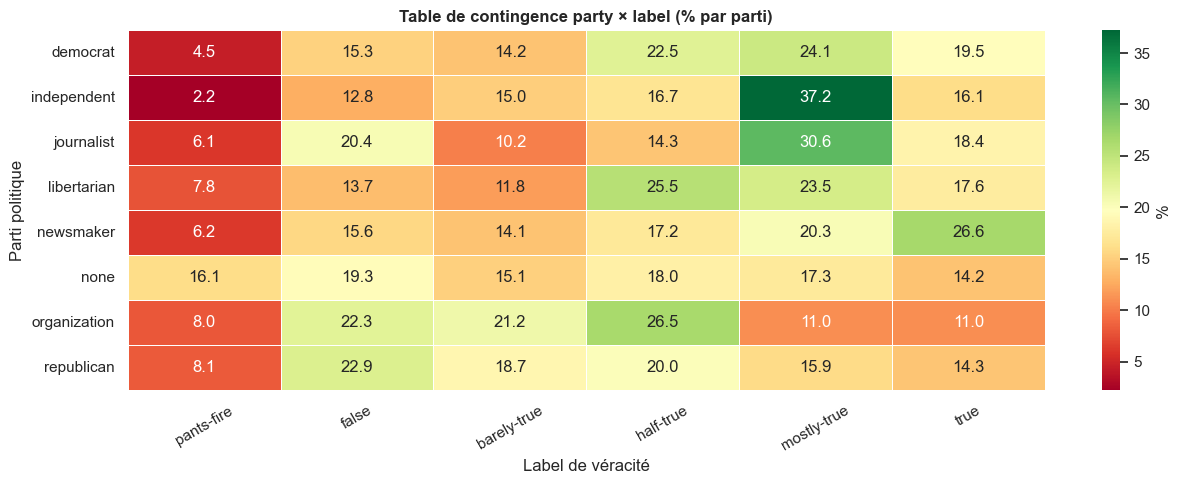

 Doc/EDA_07_contingence_party_label.png


In [35]:
top_p = liar_unifie[liar_unifie['party'] != 'unknown']['party'].value_counts().head(8).index
contingence_party = pd.crosstab(
    liar_unifie[liar_unifie['party'].isin(top_p)]['party'],
    liar_unifie[liar_unifie['party'].isin(top_p)]['label'],
    normalize='index'
).round(3) * 100

cols_present = [c for c in LABEL_ORDER if c in contingence_party.columns]
contingence_party = contingence_party[cols_present]

print(' Table de contingence party × label (% par parti) :\n')
print(contingence_party.round(1).to_string())

plt.figure(figsize=(13, 5))
sns.heatmap(contingence_party, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': '%'})
plt.title('Table de contingence party × label (% par parti)', fontweight='bold')
plt.xlabel('Label de véracité')
plt.ylabel('Parti politique')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../Doc/EDA_07_contingence_party_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/EDA_07_contingence_party_label.png')

## 8. Table de contingence subject × label

> Sujets dominants et leur lien avec la véracité (rapport section 3.3).

 Taux fake/real par sujet (top 10) :

                      fake (%)  real (%)
subject                                 
candidates-biography      52.7      47.3
economy                   34.1      65.9
economy,jobs              28.9      71.1
education                 35.3      64.7
elections                 44.7      55.3
federal-budget            30.3      69.7
guns                      39.5      60.5
health-care               52.1      47.9
immigration               48.2      51.8
taxes                     41.3      58.7


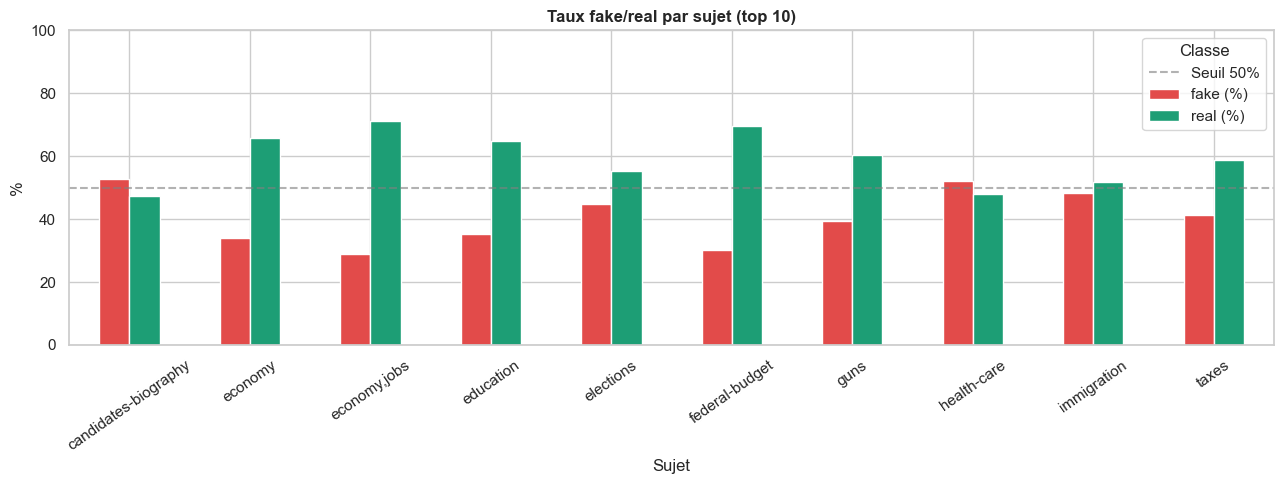

 Doc/EDA_08_subject_label.png


In [36]:
top_subj = liar_unifie[liar_unifie['subject'] != 'unknown']['subject'].value_counts().head(10).index
subj_label = pd.crosstab(
    liar_unifie[liar_unifie['subject'].isin(top_subj)]['subject'],
    liar_unifie[liar_unifie['subject'].isin(top_subj)]['binary_label'],
    normalize='index'
).round(3) * 100
subj_label.columns = ['fake (%)', 'real (%)']

print(' Taux fake/real par sujet (top 10) :\n')
print(subj_label.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
subj_label.plot(kind='bar', ax=ax, color=['#E24B4A', '#1D9E75'], edgecolor='white')
ax.set_title('Taux fake/real par sujet (top 10)', fontweight='bold')
ax.set_xlabel('Sujet')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='Seuil 50%')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Classe')
plt.tight_layout()
plt.savefig('../Doc/EDA_08_subject_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/EDA_08_subject_label.png')

## 9. Taux de fake par speaker

> Identification des speakers les plus associés aux fausses déclarations.

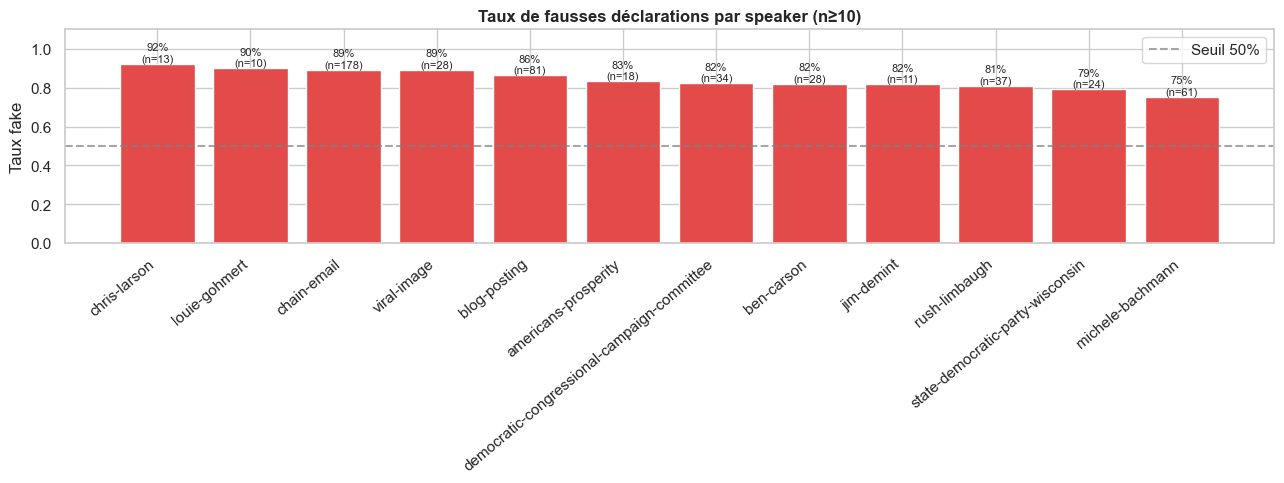

 Doc/EDA_09_fake_rate_speaker.png


In [37]:
spk_stats = (
    liar_unifie[liar_unifie['speaker'] != 'unknown']
    .groupby('speaker')['binary_label']
    .agg(total='count', fake_count=lambda x: (x == 0).sum())
    .query('total >= 10')
    .copy()
)
spk_stats['fake_rate'] = spk_stats['fake_count'] / spk_stats['total']
spk_stats = spk_stats.sort_values('fake_rate', ascending=False).head(12)

plt.figure(figsize=(13, 5))
cols_spk = ['#E24B4A' if r > 0.65 else '#EF9F27' if r > 0.45 else '#1D9E75'
            for r in spk_stats['fake_rate']]
bars = plt.bar(spk_stats.index, spk_stats['fake_rate'], color=cols_spk, edgecolor='white')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Seuil 50%')
for bar, val, n in zip(bars, spk_stats['fake_rate'], spk_stats['total']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.0%}\n(n={n})', ha='center', fontsize=8)
plt.title('Taux de fausses déclarations par speaker (n≥10)', fontweight='bold')
plt.ylabel('Taux fake')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('../Doc/EDA_09_fake_rate_speaker.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/EDA_09_fake_rate_speaker.png')

## 10. Comparaison LIAR vs BuzzFeed — Domain Shift

> Conformément au rapport (section 3.4).

In [38]:
import urllib.request
BUZZFEED_URL = (
    'https://raw.githubusercontent.com/BuzzFeedNews/'
    '2016-10-facebook-fact-check/master/data/facebook-fact-check.csv'
)
print(' Chargement BuzzFeed...')
try:
    buzz_df = pd.read_csv(BUZZFEED_URL)
    BUZZ_MAP = {
        'mostly true': 1, 'mixture of true and false': 1,
        'mostly false': 0, 'no factual content': 0,
    }
    buzz_df['binary_label'] = buzz_df['Rating'].str.lower().map(BUZZ_MAP)
    buzz_df = buzz_df.dropna(subset=['binary_label', 'title']).copy()
    buzz_df['binary_label'] = buzz_df['binary_label'].astype(int)
    buzz_df['n_tokens'] = buzz_df['title'].fillna('').apply(lambda x: len(x.split()))
    buzz_df['n_chars']  = buzz_df['title'].fillna('').apply(len)
    print(f' {len(buzz_df)} articles chargés')
except Exception as e:
    print(f' {e}')
    buzz_df = None

 Chargement BuzzFeed...
 ['title']


In [39]:
if buzz_df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Longueur
    axes[0].hist(liar_unifie['n_tokens'], bins=30, alpha=0.7, color='#7F77DD',
                 label=f'LIAR (moy={liar_unifie["n_tokens"].mean():.1f})', edgecolor='white')
    axes[0].hist(buzz_df['n_tokens'], bins=30, alpha=0.7, color='#EF9F27',
                 label=f'BuzzFeed (moy={buzz_df["n_tokens"].mean():.1f})', edgecolor='white')
    axes[0].set_title('Longueur textes : LIAR vs BuzzFeed', fontweight='bold')
    axes[0].set_xlabel('Nombre de mots')
    axes[0].legend()

    # Distribution LIAR
    liar_bin = liar_unifie['binary_label'].value_counts(normalize=True) * 100
    axes[1].bar(['fake','real'], liar_bin.reindex([0,1]).values,
                color=['#E24B4A','#1D9E75'], edgecolor='white')
    axes[1].set_title('Distribution LIAR (%)', fontweight='bold')
    axes[1].set_ylim(0, 100)
    for i, v in enumerate(liar_bin.reindex([0,1]).values):
        axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

    # Distribution BuzzFeed
    buzz_bin = buzz_df['binary_label'].value_counts(normalize=True) * 100
    axes[2].bar(['fake','real'], buzz_bin.reindex([0,1]).values,
                color=['#E24B4A','#1D9E75'], edgecolor='white')
    axes[2].set_title('Distribution BuzzFeed (%)', fontweight='bold')
    axes[2].set_ylim(0, 100)
    for i, v in enumerate(buzz_bin.reindex([0,1]).values):
        axes[2].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.suptitle('Comparaison LIAR vs BuzzFeed — Domain Shift', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Doc/EDA_10_liar_vs_buzzfeed.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Doc/EDA_10_liar_vs_buzzfeed.png')

    # Tableau comparatif
    summary = pd.DataFrame({
        'Dataset': ['LIAR', 'BuzzFeed'],
        'N exemples': [len(liar_unifie), len(buzz_df)],
        'N tokens moy.': [round(liar_unifie['n_tokens'].mean(),1), round(buzz_df['n_tokens'].mean(),1)],
        '% fake': [round((liar_unifie['binary_label']==0).mean()*100,1),
                   round((buzz_df['binary_label']==0).mean()*100,1)],
        'Type texte': ['Déclarations directes', 'Titres articles FB'],
    })
    print('\n Tableau comparatif :')
    print(summary.to_string(index=False))

## 11. Sauvegarde finale avec toutes les features

In [40]:
# Sauvegarde avec n_chars et n_tokens
liar_unifie.to_parquet('../data/traitees/liar_eda_features.parquet', index=False)
liar_unifie.to_csv('../data/fusionnes/liar_unifie.csv', index=False)

print(' Résumé final :')
print(f'  Total déclarations : {len(liar_unifie):,}')
print(f'  Speakers uniques   : {liar_unifie["speaker"].nunique():,}')
print(f'  Partis uniques     : {liar_unifie["party"].nunique():,}')
print(f'  Sujets uniques     : {liar_unifie["subject"].nunique():,}')
print(f'  Longueur moy.      : {liar_unifie["n_tokens"].mean():.1f} mots')
print(f'  % fake             : {(liar_unifie["binary_label"]==0).mean()*100:.1f}%')
print(f'  % real             : {(liar_unifie["binary_label"]==1).mean()*100:.1f}%')
print(f'  Valeurs manquantes : 0 (remplacées par unknown)')
print('\n Graphiques générés dans Doc/ :')
for i, name in enumerate(['EDA_01_distribution_labels.png','EDA_02_distribution_binaire.png',
    'EDA_03_top_speakers.png','EDA_04_labels_by_party.png','EDA_05_text_length.png',
    'EDA_06_nchars_ntokens.png','EDA_07_contingence_party_label.png',
    'EDA_08_subject_label.png','EDA_09_fake_rate_speaker.png','EDA_10_liar_vs_buzzfeed.png'], 1):
    print(f'   {i:02d}. {name}')
print('\n EDA complète → lancer Modeles_de_Base.ipynb')

 Résumé final :
  Total déclarations : 12,791
  Speakers uniques   : 3,310
  Partis uniques     : 25
  Sujets uniques     : 4,535
  Longueur moy.      : 18.0 mots
  % fake             : 44.2%
  % real             : 55.8%
  Valeurs manquantes : 0 (remplacées par unknown)

 Graphiques générés dans Doc/ :
   01. EDA_01_distribution_labels.png
   02. EDA_02_distribution_binaire.png
   03. EDA_03_top_speakers.png
   04. EDA_04_labels_by_party.png
   05. EDA_05_text_length.png
   06. EDA_06_nchars_ntokens.png
   07. EDA_07_contingence_party_label.png
   08. EDA_08_subject_label.png
   09. EDA_09_fake_rate_speaker.png
   10. EDA_10_liar_vs_buzzfeed.png

 EDA complète → lancer Modeles_de_Base.ipynb
